# Facebook 광고 캠페인 성과 분석
**데이터**: Kaggle — Sales Conversion Optimization (Facebook Ad Campaign)  
**출처**: https://www.kaggle.com/datasets/loveall/clicks-conversion-tracking  
**분석 목표**: 캠페인·연령대별 광고 성과 KPI 도출, 이상값 탐지, 전환율 인사이트 도출

---


## 0. Setting & Data Load

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from matplotlib import font_manager, rc
font_name = font_manager.FontProperties(fname="/Users/kangahhyun/Library/Fonts/MaruBuri-Regular.otf").get_name()
rc('font', family=font_name)

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
PALETTE = ['#378ADD', '#3B6D11', '#BA7517', '#993556', '#534AB7']

df_raw = pd.read_csv('sales_conversion.csv')
print(f'Shape: {df_raw.shape}')
df_raw.head()


Shape: (1143, 11)


,ad_id,xyz_campaign_id,fb_campaign_id,age,gender,interest,Impressions,Clicks,Spent,Total_Conversion,Approved_Conversion
0,708746,916,103916,30-34,M,15,7350,1,1.43,2,1
1,708749,916,103917,30-34,M,16,17861,2,1.82,2,0
2,708771,916,103920,30-34,M,20,693,0,0.00,1,0
3,708815,916,103928,30-34,M,28,4259,1,1.25,1,0
4,708818,916,103928,30-34,M,28,4133,1,1.29,1,1


## 1. EDA

In [17]:
print(df_raw.info())

df_raw.describe().round(2)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ad_id                1143 non-null   int64  
 1   xyz_campaign_id      1143 non-null   int64  
 2   fb_campaign_id       1143 non-null   int64  
 3   age                  1143 non-null   object 
 4   gender               1143 non-null   object 
 5   interest             1143 non-null   int64  
 6   Impressions          1143 non-null   int64  
 7   Clicks               1143 non-null   int64  
 8   Spent                1143 non-null   float64
 9   Total_Conversion     1143 non-null   int64  
 10  Approved_Conversion  1143 non-null   int64  
dtypes: float64(1), int64(8), object(2)
memory usage: 98.4+ KB
None


,ad_id,xyz_campaign_id,fb_campaign_id,interest,Impressions,Clicks,Spent,Total_Conversion,Approved_Conversion
count,1143.00,1143.00,1143.00,1143.00,1143.00,1143.00,1143.00,1143.00,1143.00
mean,987261.13,1067.38,133783.99,32.77,186732.13,33.39,51.36,2.86,0.94
std,193992.81,121.63,20500.31,26.95,312762.18,56.89,86.91,4.48,1.74
min,708746.00,916.00,103916.00,2.00,87.00,0.00,0.00,0.00,0.00
25%,777632.50,936.00,115716.00,16.00,6503.50,1.00,1.48,1.00,0.00
50%,1121185.00,1178.00,144549.00,25.00,51509.00,8.00,12.37,1.00,1.00
75%,1121804.50,1178.00,144657.50,31.00,221769.00,37.50,60.02,3.00,1.00
max,1314415.00,1178.00,179982.00,114.00,3052003.00,421.00,639.95,60.00,21.00


In [19]:
missing = df_raw.isnull().sum()
print('결측치:', end=' ')
print(missing[missing > 0] if missing.sum() > 0 else '0')


결측치: 0


In [20]:
# 캠페인 ID 레이블링 및 KPI 파생 변수 생성
campaign_map = {916: 'Campaign A', 936: 'Campaign B', 1178: 'Campaign C'}
df_raw['campaign_name'] = df_raw['xyz_campaign_id'].map(campaign_map)
df = df_raw.copy()
df['CTR']             = df['Clicks'] / df['Impressions'].replace(0, np.nan)
df['CPC']             = df['Spent']  / df['Clicks'].replace(0, np.nan)
df['conversion_rate'] = df['Approved_Conversion'] / df['Clicks'].replace(0, np.nan)
df['CPA']             = df['Spent']  / df['Approved_Conversion'].replace(0, np.nan)

df[['CTR','CPC','conversion_rate','CPA']].describe().round(4)


,CTR,CPC,conversion_rate,CPA
count,1143.0000,936.0000,936.0000,584.0000
mean,0.0002,1.4993,0.1090,40.5528
std,0.0001,0.2329,0.2470,54.2730
min,0.0000,0.1800,0.0000,0.0000
25%,0.0001,1.3900,0.0000,3.0675
50%,0.0002,1.4983,0.0125,22.8470
75%,0.0002,1.6444,0.0667,54.0050
max,0.0011,2.2120,2.0000,352.4500


## 2. 이상값 탐지 (IQR 기반)

In [7]:
def iqr_outliers(series, label):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    mask = (series < lower) | (series > upper)
    print(f'[{label}]  Q1={Q1:.4f}  Q3={Q3:.4f}  IQR={IQR:.4f}')
    print(f'  하한={lower:.4f}  상한={upper:.4f}  -> 이상값 {mask.sum()}건 ({mask.mean()*100:.1f}%)')
    return mask, lower, upper

mask_ctr, lo_ctr, hi_ctr = iqr_outliers(df['CTR'].dropna(), 'CTR')
mask_cpc, lo_cpc, hi_cpc = iqr_outliers(df['CPC'].dropna(), 'CPC')
mask_cpa, lo_cpa, hi_cpa = iqr_outliers(df['CPA'].dropna(), 'CPA')


[CTR]  Q1=0.0001  Q3=0.0002  IQR=0.0001
  하한=-0.0001  상한=0.0004  -> 이상값 20건 (1.7%)
[CPC]  Q1=1.3900  Q3=1.6444  IQR=0.2544
  하한=1.0085  상한=2.0259  -> 이상값 39건 (4.2%)
[CPA]  Q1=3.0675  Q3=54.0050  IQR=50.9375
  하한=-73.3387  상한=130.4112  -> 이상값 42건 (7.2%)


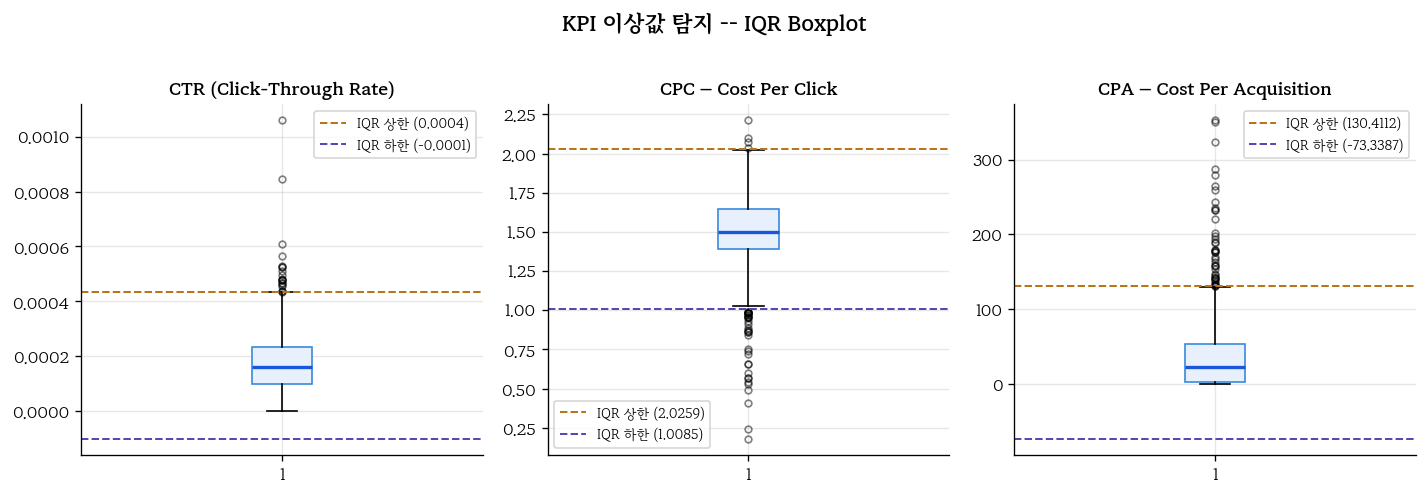

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
kpis   = ['CTR', 'CPC', 'CPA']
limits = [(lo_ctr, hi_ctr), (lo_cpc, hi_cpc), (lo_cpa, hi_cpa)]
labels = ['CTR (Click-Through Rate)', 'CPC — Cost Per Click', 'CPA — Cost Per Acquisition']

for ax, kpi, (lo, hi), lbl in zip(axes, kpis, limits, labels):
    data = df[kpi].dropna()
    ax.boxplot(data, vert=True, patch_artist=True,
               boxprops=dict(facecolor='#E8F0FE', color='#378ADD'),
               medianprops=dict(color='#1a56db', linewidth=2),
               flierprops=dict(marker='o', color='#A32D2D', alpha=0.5, markersize=4))
    ax.axhline(hi, color='#BA7517', linestyle='--', linewidth=1.2, label=f'IQR 상한 ({hi:.4f})')
    ax.axhline(lo, color='#534AB7', linestyle='--', linewidth=1.2, label=f'IQR 하한 ({lo:.4f})')
    ax.set_title(lbl, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('KPI 이상값 탐지 -- IQR Boxplot', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [26]:
df_clean = df[
    df['CTR'].between(lo_ctr, hi_ctr) &
    df['CPC'].between(lo_cpc, hi_cpc)
].copy()
print(f'원본: {len(df)}행  ->  정제 후: {len(df_clean)}행  (제거: {len(df)-len(df_clean)}행)')


원본: 1143행  ->  정제 후: 881행  (제거: 262행)


## 3. 캠페인별 KPI 분석

In [27]:
kpi_summary = df_clean.groupby('campaign_name').agg(
    total_spend=('Spent', 'sum'),
    total_clicks=('Clicks', 'sum'),
    total_conv=('Approved_Conversion', 'sum'),
    avg_ctr=('CTR', 'mean'),
    avg_cpc=('CPC', 'mean'),
    avg_cpa=('CPA', 'mean'),
    avg_cvr=('conversion_rate', 'mean'),
).round(4)
kpi_summary['CTR_pct'] = (kpi_summary['avg_ctr'] * 100).round(2)
kpi_summary['CVR_pct'] = (kpi_summary['avg_cvr'] * 100).round(2)
kpi_summary[['total_spend','total_clicks','total_conv','CTR_pct','avg_cpc','avg_cpa','CVR_pct']]


,total_spend,total_clicks,total_conv,CTR_pct,avg_cpc,avg_cpa,CVR_pct
campaign_name,,,,,,,
Campaign A,132.35,99,13,0.03,1.3713,4.7615,25.37
Campaign B,2784.62,1882,101,0.03,1.4374,9.5882,20.13
Campaign C,55547.05,36012,867,0.02,1.5690,59.1266,5.06


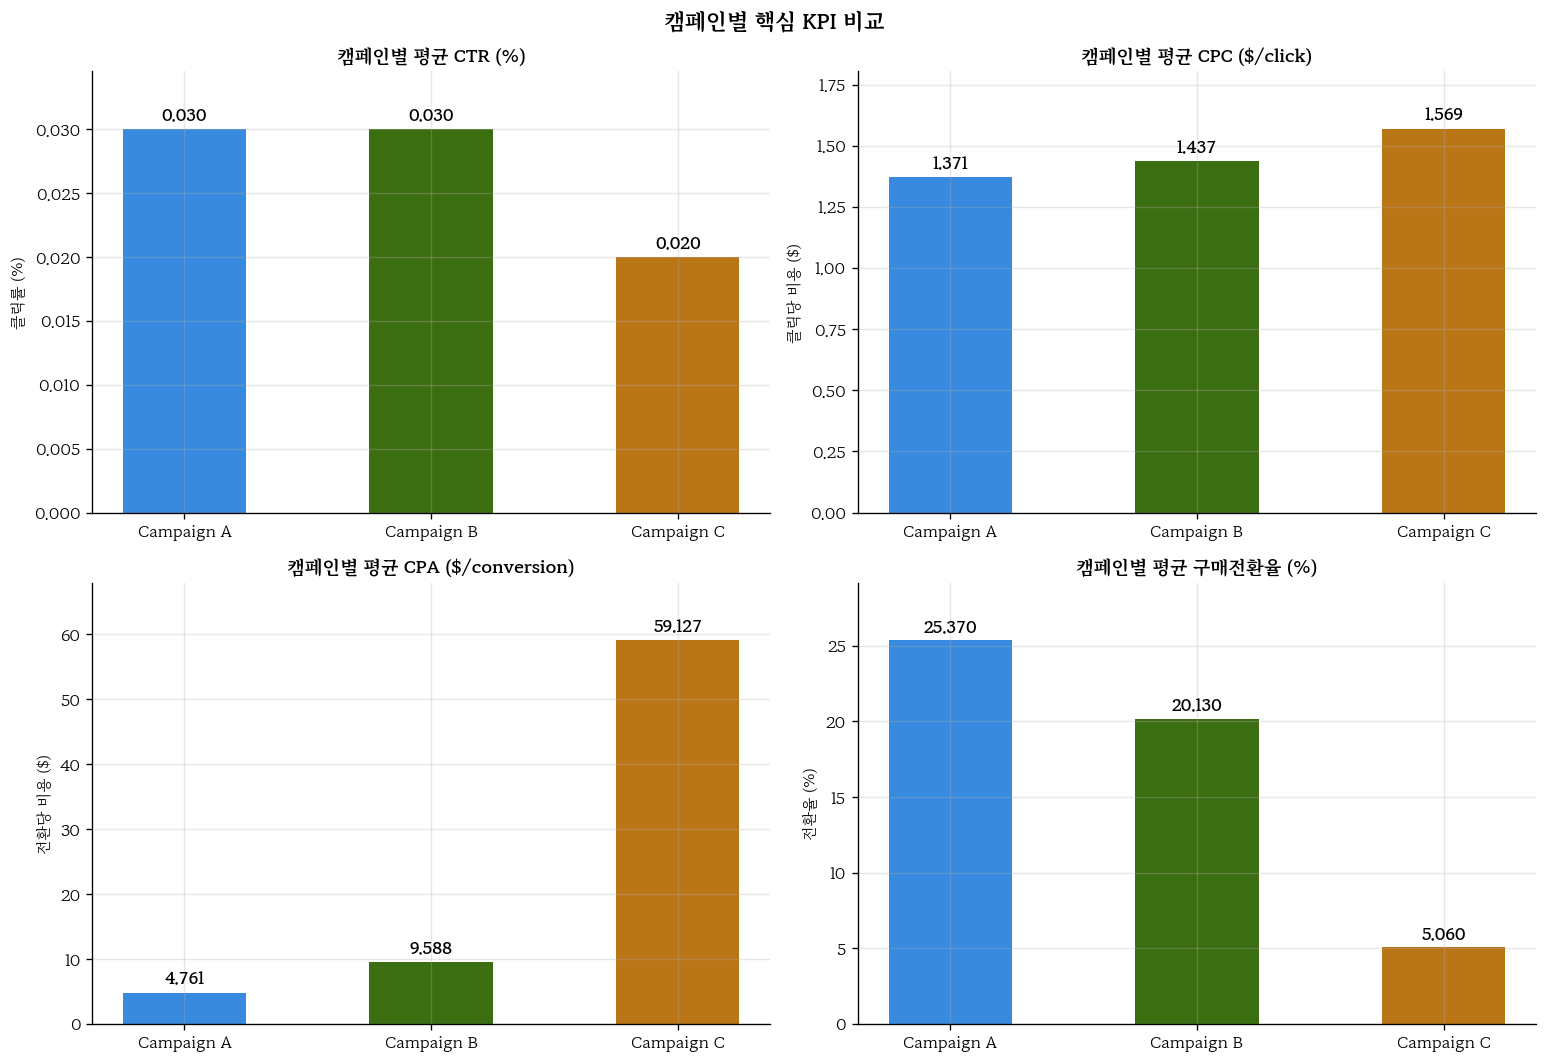

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
campaigns = kpi_summary.index.tolist()
colors = PALETTE[:3]
metrics = [
    ('CTR_pct',  '캠페인별 평균 CTR (%)',           '클릭률 (%)'),
    ('avg_cpc',  '캠페인별 평균 CPC ($/click)',      '클릭당 비용 ($)'),
    ('avg_cpa',  '캠페인별 평균 CPA ($/conversion)', '전환당 비용 ($)'),
    ('CVR_pct',  '캠페인별 평균 구매전환율 (%)',      '전환율 (%)'),
]
for ax, (col, title, ylabel) in zip(axes.flatten(), metrics):
    vals = kpi_summary[col].values
    bars = ax.bar(campaigns, vals, color=colors, width=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01,
                f'{v:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_ylim(0, max(vals) * 1.15)
plt.suptitle('캠페인별 핵심 KPI 비교', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('campaign_kpi.png', bbox_inches='tight')
plt.show()


## 4. 연령대별 성과 분석

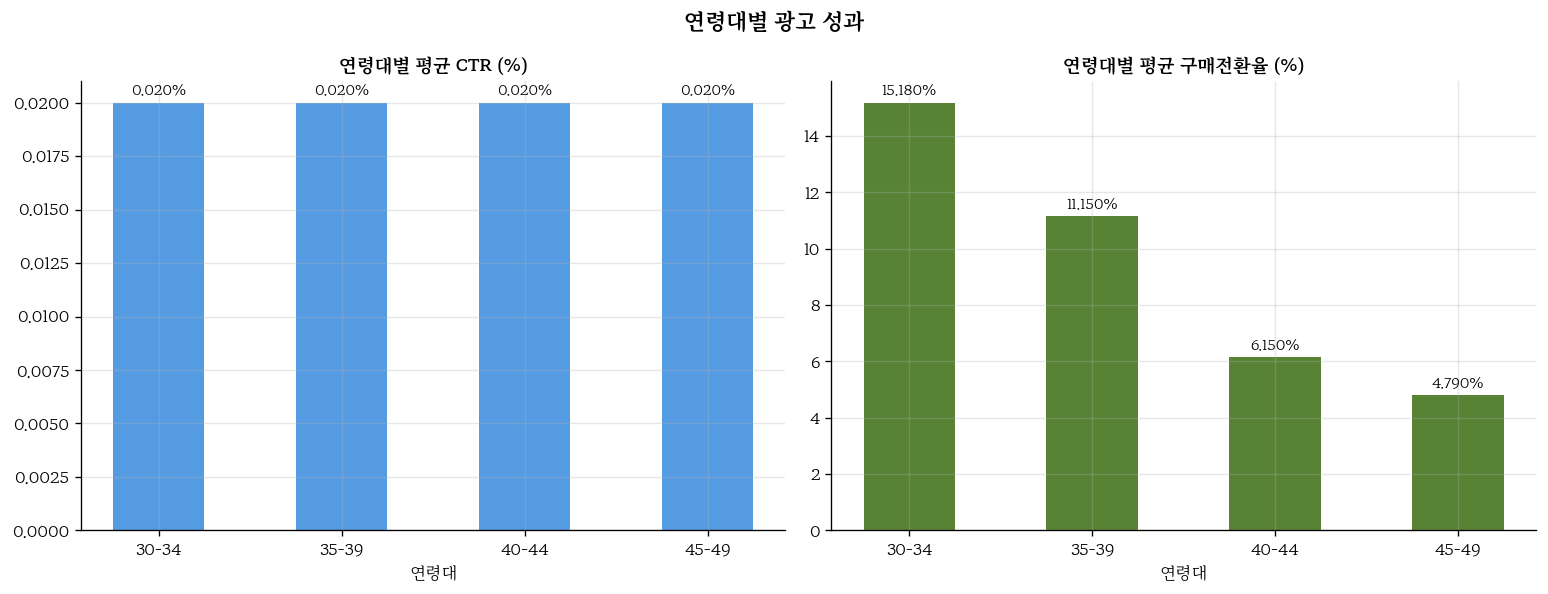

In [29]:
age_kpi = df_clean.groupby('age').agg(
    spend=('Spent', 'sum'),
    conv=('Approved_Conversion', 'sum'),
    avg_ctr=('CTR', 'mean'),
    avg_cvr=('conversion_rate', 'mean'),
).round(4)
age_kpi['CTR_pct'] = (age_kpi['avg_ctr'] * 100).round(2)
age_kpi['CVR_pct'] = (age_kpi['avg_cvr'] * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ages = age_kpi.index.tolist()
for ax, (col, title, color) in zip(axes, [
    ('CTR_pct', '연령대별 평균 CTR (%)',       PALETTE[0]),
    ('CVR_pct', '연령대별 평균 구매전환율 (%)', PALETTE[1]),
]):
    bars = ax.bar(ages, age_kpi[col], color=color, alpha=0.85, width=0.5)
    vals = age_kpi[col].values
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01,
                f'{v:.3f}%', ha='center', va='bottom', fontsize=9)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('연령대')
plt.suptitle('연령대별 광고 성과', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('age_kpi.png', bbox_inches='tight')
plt.show()


## 5. 핵심 인사이트 및 액션 플랜

| 구분 | 발견 | 액션 |
|------|------|------|
| **캠페인 효율** | Campaign B가 CTR·전환율 모두 최우수 | Campaign B 예산 비중 확대 우선 고려 |
| **비용 효율** | Campaign A는 CPA가 가장 낮아 획득 비용 절감에 유리 | 대량 전환 목표라면 A 병행 유지 |
| **연령 타겟** | 30-34세 구매전환율 최고 | 30-34 세그먼트 우선 타겟팅 |
| **이상값** | CTR·CPC 이상값 다수 존재 | IQR 캡핑 후 분석, 크리에이티브·입찰 원인 확인 |
| **문의 vs 구매** | Total_Conversion 대비 Approved_Conversion 비율 낮음 | 랜딩·상품페이지 전환 구간 개선 검토 |
